# puggles playground

A tour of what the library can do, on problems you can read end to end.

Every section is self-contained: a problem, a run, and a plot or a number that says whether it
worked. Sections 1-8 cover the capabilities added in the 2026-09-08 pass — closed bounds,
constraint-violation magnitude, permutation encoding, batch objectives on NSGA-III,
hypervolume-based stopping, the island model, and checkpointing. Sections 4-6 also race puggles
against **pymoo**, **platypus**, and **DEAP** on the same problem, same population, same
evaluation budget — a quick single-run read; `sandbox/benchmarks.md` has the full multi-seed
statistics.

Run all cells top to bottom. Total runtime is about two and a half minutes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import puggles as pg

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True, "grid.alpha": 0.25})

RNG = np.random.default_rng(7)
print("puggles", pg.__version__)
print("available:", ", ".join(n for n in ("NSGAII", "NSGAIII", "run_island_model",
                                          "hypervolume_2d", "igd", "spacing") if hasattr(pg, n)))

puggles 0.1.0
available: NSGAII, NSGAIII, run_island_model, hypervolume_2d, igd, spacing


---
## 1. Configuration errors are Python errors

Invalid bounds and malformed problems used to surface as a Rust panic — or, for an unbounded
`Real`, as a `range overflow` from inside the random-number generator on the first evaluation.
They are now validated at construction and raised as `ValueError`.

In [2]:
def expect_error(label, thunk):
    try:
        thunk()
        print(f"  no error   {label}")
    except ValueError as e:
        print(f"  ValueError {label:34} {str(e)[:58]}")

ok = lambda x: pg.Problem(1, 1, [x], lambda v: [v[0]])

expect_error("upper == lower",      lambda: ok(pg.Real(5.0, 5.0)))
expect_error("upper < lower",       lambda: ok(pg.Integer(9, 2)))
expect_error("length mismatch",     lambda: pg.Problem(3, 1, [pg.Real(0, 1)], lambda v: [v[0]]))
expect_error("unknown operator",    lambda: pg.Problem(1, 1, [pg.Real(0, 1)], lambda v: [v[0]],
                                                       objective_constraints=[1.0],
                                                       constraint_operands=["=<"]))
expect_error("bad direction",       lambda: pg.Problem(1, 1, [pg.Real(0, 1)], lambda v: [v[0]],
                                                       direction=[0]))
# Built-in benchmarks derive their objective count from the solution length, so asking for
# the wrong one is easy. That mismatch used to surface as an index-out-of-bounds panic from
# inside the dominance comparison, mid-run; it is checked at construction now.
expect_error("benchmark arity mismatch",
             lambda: pg.create_benchmark_problem("paraboloid_5_loc", 5, 2, [(-5.0, 5.0)] * 5))

print("\nvalid problem builds fine:", ok(pg.Real(0.0, 1.0)))

  ValueError upper == lower                     Lower bound must not be equal to upper bound
  ValueError upper < lower                      Lower bound must be less than upper bound
  ValueError length mismatch                    solution_length does not match solution_data_types length
  ValueError unknown operator                   Invalid operand: =< (expected one of <, >, <=, >=, ==, !=)
  ValueError bad direction                      direction entries must be 1 (maximize) or -1 (minimize), g
  ValueError benchmark arity mismatch           benchmark 'paraboloid_5_loc' returns 1 objective(s) at sol

valid problem builds fine: Problem(solution_length=1, number_of_objectives=1)


---
## 2. Bounds are closed on both ends

`Integer(0, 10)` means `0..=10`. Generation, crossover, and mutation all draw from and clamp into
the same closed interval, so an optimum sitting exactly on the upper bound is reachable.

Generation used to be half-open while every operator clamped into the closed interval, so the
upper bound was reachable by mutation but could never appear in an initial population. Two checks
below: that the upper bound is generated at all, then that an optimum sitting on it is found.

In [3]:
HI = 10

# Direct evidence. run(max_nfe=population_size) spends its whole budget priming, so no
# generation runs and get_population() is the freshly generated initial population.
probe = pg.Problem(1, 1, [pg.Integer(0, HI)], lambda x: [x[0]], direction=[1])
seeded = pg.NSGAII(probe, population_size=400, seed=1)
seeded.run(400)

values = sorted({int(s.variables[0]) for s in seeded.get_population()})
print(f"values generated for Integer(0, {HI}) : {values}")
print(f"upper bound {HI} appears in the initial population: {HI in values}")

# End to end: maximize the sum of eight integers in [0, 10]. The only optimum puts every
# gene on the upper bound, so it is unreachable unless generation is closed.
N_VARS = 8
problem = pg.Problem(
    solution_length=N_VARS,
    number_of_objectives=1,
    solution_data_types=[pg.Integer(0, HI)] * N_VARS,
    objective_function=lambda x: [sum(x)],
    direction=[1],                     # maximize
)

ga = pg.NSGAII(problem, population_size=200, seed=1)
ga.run(60_000)

best = max(ga.get_archive(), key=lambda s: s.objectives[0])
genes = [int(v) for v in best.variables]
print(f"\nbest total : {best.objectives[0]:.0f}  (optimum {N_VARS * HI})")
print(f"genes      : {genes}")
print(f"every gene on the closed upper bound: {all(g == HI for g in genes)}")

# Worth knowing: this problem needs the population, not the budget. A population of 40
# converges prematurely and stalls at 76 no matter how many evaluations you spend, because
# uniform crossover only reshuffles existing genes once diversity is gone.
small = pg.NSGAII(problem, population_size=40, seed=1)
small.run(100_000)
print(f"\npopulation 40, 100,000 evals : {max(s.objectives[0] for s in small.get_archive()):.0f}  (stalled)")
print(f"population 200, 60,000 evals : {best.objectives[0]:.0f}")

values generated for Integer(0, 10) : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
upper bound 10 appears in the initial population: True

best total : 80  (optimum 80)
genes      : [10, 10, 10, 10, 10, 10, 10, 10]
every gene on the closed upper bound: True

population 40, 100,000 evals : 76  (stalled)
population 200, 60,000 evals : 80


---
## 3. Constraint violation has a magnitude, not just a count

`Solution.constraint_violation` counts how many constraints are broken.
`Solution.constraint_violation_magnitude` measures *by how much*.

That distinction decides ranking. Two solutions that each break one constraint used to tie, and
the comparison fell through to their objective values — which are not yet meaningful for an
infeasible solution. Now the one closer to feasibility wins, so the search is pulled toward the
feasible region instead of drifting along it.

**Problem.** Minimize `f1 = Σ(x-2)²` and `f2 = Σ(x+2)²` over `x ∈ [-5, 5]^4`, subject to
`f1 ≤ 10`. The two objectives pull in opposite directions, and the constraint rules out the half
of the front that minimizes `f2`. A solution with `f1 > 10` is infeasible by exactly `f1 - 10`.

In [4]:
DIM, F1_CAP = 4, 10.0

def two_wells(x):
    a = np.asarray(x)
    return [float(((a - 2.0) ** 2).sum()), float(((a + 2.0) ** 2).sum())]

constrained = pg.Problem(
    solution_length=DIM,
    number_of_objectives=2,
    solution_data_types=[pg.Real(-5.0, 5.0)] * DIM,
    objective_function=two_wells,
    direction=[-1, -1],
    objective_constraints=[F1_CAP, None],     # f1 <= 10, f2 unconstrained
    constraint_operands=["<=", None],
)

# Track how the population's infeasibility shrinks, generation by generation.
history = []
def watch(archive, population, nfe):
    infeasible = [s for s in population if not s.feasible]
    history.append((
        nfe,
        len(infeasible) / len(population),
        float(np.mean([s.constraint_violation_magnitude for s in infeasible])) if infeasible else 0.0,
    ))

ga = pg.NSGAII(constrained, population_size=60, seed=3)
ga.run(12_000, callback=watch)

arch = ga.get_archive()
print(f"archive           : {len(arch)} solutions")
print(f"all feasible      : {all(s.feasible for s in arch)}")
print(f"max f1 in archive : {max(s.objectives[0] for s in arch):.3f}  (cap {F1_CAP})")
print(f"magnitude (archive): {max(s.constraint_violation_magnitude for s in arch):.3f}  (0.0 when feasible)")
print(f"\nfirst generation  : {history[0][1]:.0%} infeasible, mean overshoot {history[0][2]:.2f}")
print(f"last generation   : {history[-1][1]:.0%} infeasible, mean overshoot {history[-1][2]:.2f}")

archive           : 60 solutions
all feasible      : True
max f1 in archive : 9.985  (cap 10.0)
magnitude (archive): 0.000  (0.0 when feasible)

first generation  : 88% infeasible, mean overshoot 20.76
last generation   : 0% infeasible, mean overshoot 0.00


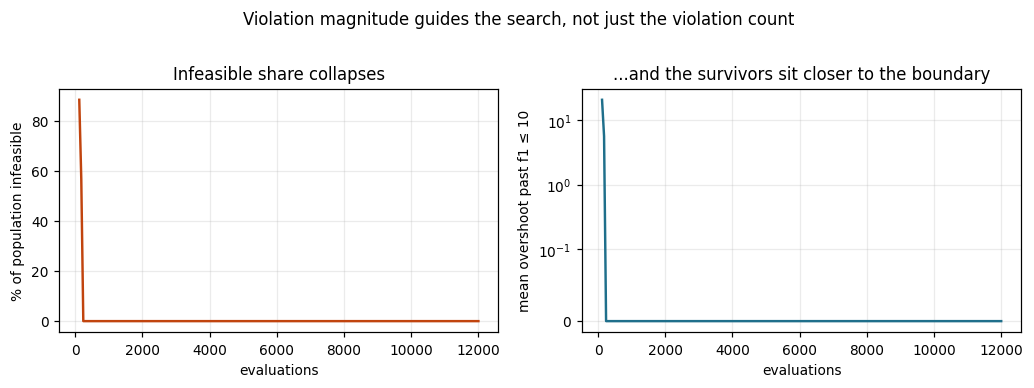

In [5]:
nfe, frac, mag = np.array(history).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.4))

ax1.plot(nfe, frac * 100, lw=1.6, color="#c1440e")
ax1.set(xlabel="evaluations", ylabel="% of population infeasible",
        title="Infeasible share collapses")

ax2.plot(nfe, mag, lw=1.6, color="#1f6f8b")
ax2.set(xlabel="evaluations", ylabel="mean overshoot past f1 ≤ 10",
        title="...and the survivors sit closer to the boundary")
ax2.set_yscale("symlog", linthresh=0.1)

fig.suptitle("Violation magnitude guides the search, not just the violation count", y=1.02)
fig.tight_layout()
plt.show()

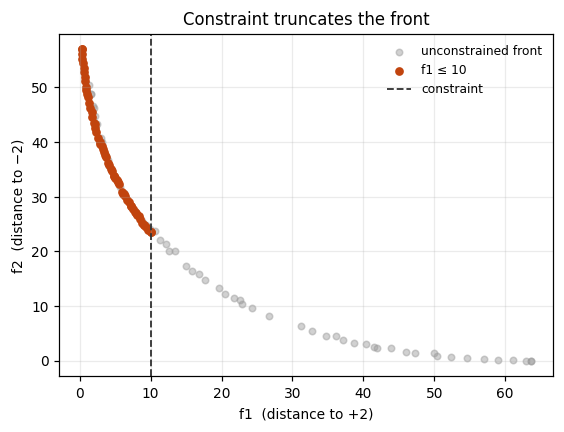

In [6]:
# The constrained front: only the f1 <= 10 half survives.
unconstrained = pg.Problem(DIM, 2, [pg.Real(-5.0, 5.0)] * DIM, two_wells, direction=[-1, -1])
free = pg.NSGAII(unconstrained, population_size=60, seed=3)
free.run(12_000)

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.scatter([s.objectives[0] for s in free.get_archive()],
           [s.objectives[1] for s in free.get_archive()],
           s=18, alpha=0.45, label="unconstrained front", color="#999999")
ax.scatter([s.objectives[0] for s in arch], [s.objectives[1] for s in arch],
           s=22, label="f1 ≤ 10", color="#c1440e")
ax.axvline(F1_CAP, ls="--", lw=1.2, color="#333333", label="constraint")
ax.set(xlabel="f1  (distance to +2)", ylabel="f2  (distance to −2)",
       title="Constraint truncates the front")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

---
## 4. Permutation encoding — a travelling salesman tour

Ordering problems need whole-vector variation. Blending two tours, or resampling a single gene,
produces a sequence that visits one city twice and another never. Passing `permutation=True`
switches the GA to order crossover (OX1) and swap mutation, which preserve the permutation.

**Problem.** A closed tour over 14 random cities, minimizing total distance.

In [7]:
N_CITIES = 50
CITIES = RNG.random((N_CITIES, 2)) * 100
DIST = np.linalg.norm(CITIES[:, None, :] - CITIES[None, :, :], axis=-1)

def tour_length(order):
    idx = np.asarray(order, dtype=int)
    return [float(DIST[idx, np.roll(idx, -1)].sum())]

tsp = pg.Problem(
    solution_length=N_CITIES,
    number_of_objectives=1,
    solution_data_types=[pg.Integer(0, N_CITIES - 1)] * N_CITIES,
    objective_function=tour_length,
    direction=[-1],
    permutation=True,
)
print("permutation encoding:", tsp.permutation)

# Baseline: the best of many random tours, on the same evaluation budget.
BUDGET = 300_000
rand_best, rand_tour = np.inf, None
for _ in range(BUDGET // 10):
    cand = RNG.permutation(N_CITIES)
    d = tour_length(cand)[0]
    if d < rand_best:
        rand_best, rand_tour = d, cand

ga = pg.NSGAII(tsp, population_size=60, seed=11)
ga.run(BUDGET)
best = min(ga.get_archive(), key=lambda s: s.objectives[0])
ga_tour = np.array([int(v) for v in best.variables])

assert sorted(ga_tour.tolist()) == list(range(N_CITIES)), "not a permutation!"
print(f"random best : {rand_best:8.2f}")
print(f"puggles     : {best.objectives[0]:8.2f}   ({100 * (1 - best.objectives[0] / rand_best):.1f}% shorter)")
print(f"valid tour  : {sorted(ga_tour.tolist()) == list(range(N_CITIES))}")

permutation encoding: True


random best :  2085.07
puggles     :   798.13   (61.7% shorter)
valid tour  : True


**vs. other libraries.** platypus and pymoo both ship native permutation support (`Permutation`
type / `OrderCrossover` + `InversionMutation`); DEAP's classic TSP recipe composes `cxOrdered` +
`mutShuffleIndexes` by hand. Same cities, same population, same evaluation budget.

In [8]:
import random as _random
import time as _time

POP_CMP, NFE_CMP = 60, 60_000  # shared budget — smaller than the 300k run above, sized for a fair race

def _puggles_tsp():
    p = pg.NSGAII(tsp, population_size=POP_CMP, seed=11)
    t0 = _time.perf_counter(); p.run(NFE_CMP)
    return (_time.perf_counter() - t0) * 1000, min(s.objectives[0] for s in p.get_archive())

def _platypus_tsp():
    from platypus import GeneticAlgorithm, Problem as _P, Permutation
    prob = _P(1, 1)
    prob.types[:] = Permutation(range(N_CITIES))
    prob.function = lambda v: [tour_length(v[0])[0]]
    alg = GeneticAlgorithm(prob, population_size=POP_CMP)
    t0 = _time.perf_counter(); alg.run(NFE_CMP)
    return (_time.perf_counter() - t0) * 1000, min(s.objectives[0] for s in alg.result)

def _pymoo_tsp():
    from pymoo.core.problem import ElementwiseProblem
    from pymoo.algorithms.soo.nonconvex.ga import GA
    from pymoo.operators.sampling.rnd import PermutationRandomSampling
    from pymoo.operators.crossover.ox import OrderCrossover
    from pymoo.operators.mutation.inversion import InversionMutation
    from pymoo.optimize import minimize

    class _TSP(ElementwiseProblem):
        def __init__(s):
            super().__init__(n_var=N_CITIES, n_obj=1, xl=0, xu=N_CITIES - 1, vtype=int)
        def _evaluate(s, x, out, *a, **k):
            out["F"] = tour_length(x)[0]

    algo = GA(pop_size=POP_CMP, sampling=PermutationRandomSampling(),
              crossover=OrderCrossover(), mutation=InversionMutation(), eliminate_duplicates=True)
    t0 = _time.perf_counter()
    res = minimize(_TSP(), algo, ("n_evals", NFE_CMP), verbose=False)
    return (_time.perf_counter() - t0) * 1000, float(res.F[0])

def _deap_tsp():
    from deap import base, creator, tools
    if not hasattr(creator, "_TSPFit"):
        creator.create("_TSPFit", base.Fitness, weights=(-1.0,))
    if not hasattr(creator, "_TSPInd"):
        creator.create("_TSPInd", list, fitness=creator._TSPFit)
    tb = base.Toolbox()
    tb.register("indices", _random.sample, range(N_CITIES), N_CITIES)
    tb.register("individual", tools.initIterate, creator._TSPInd, tb.indices)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("evaluate", lambda ind: (tour_length(ind)[0],))
    tb.register("mate", tools.cxOrdered)
    tb.register("mutate", tools.mutShuffleIndexes, indpb=0.02)
    tb.register("select", tools.selTournament, tournsize=3)

    gens = (NFE_CMP - POP_CMP) // POP_CMP
    t0 = _time.perf_counter()
    pop = tb.population(n=POP_CMP)
    for ind in pop:
        ind.fitness.values = tb.evaluate(ind)
    for _ in range(gens):
        offspring = [tb.clone(i) for i in tb.select(pop, POP_CMP)]
        for c1, c2 in zip(offspring[::2], offspring[1::2]):
            if _random.random() < 0.7:
                tb.mate(c1, c2)
                del c1.fitness.values, c2.fitness.values
        for m in offspring:
            if _random.random() < 0.3:
                tb.mutate(m)
                del m.fitness.values
        for ind in offspring:
            if not ind.fitness.valid:
                ind.fitness.values = tb.evaluate(ind)
        pop = offspring
    dt = (_time.perf_counter() - t0) * 1000
    return dt, min(i.fitness.values[0] for i in pop)

print(f"# TSP  {N_CITIES} cities  pop={POP_CMP}  NFE={NFE_CMP:,}   metric = tour length (lower=better)")
print(f"{'library':<12} {'ms':>10} {'tour':>10}")
print("─" * 34)
_tsp_results = {}
for name, fn in [("puggles", _puggles_tsp), ("pymoo", _pymoo_tsp),
                  ("platypus", _platypus_tsp), ("DEAP", _deap_tsp)]:
    ms, length = fn()
    _tsp_results[name] = (ms, length)
    print(f"{name:<12} {ms:>10.1f} {length:>10.1f}")

_fastest = min(_tsp_results, key=lambda n: _tsp_results[n][0])
_shortest = min(_tsp_results, key=lambda n: _tsp_results[n][1])
if _fastest != _shortest:
    speedup = _tsp_results[_shortest][0] / _tsp_results["puggles"][0]
    gap = 100 * (_tsp_results["puggles"][1] - _tsp_results[_shortest][1]) / _tsp_results[_shortest][1]
    print(f"\nhonest tradeoff: puggles is {speedup:.1f}× faster than {_shortest} here, but swap "
          f"mutation finds a tour {gap:.0f}% longer than {_shortest}'s inversion mutation — a "
          "better TSP-specific operator, not a faster-search win.")

# TSP  50 cities  pop=60  NFE=60,000   metric = tour length (lower=better)
library              ms       tour
──────────────────────────────────


puggles           430.0      798.1


pymoo            2389.3      641.9


platypus         3625.2      687.2


DEAP              925.6      840.9

honest tradeoff: puggles is 5.6× faster than pymoo here, but swap mutation finds a tour 24% longer than pymoo's inversion mutation — a better TSP-specific operator, not a faster-search win.


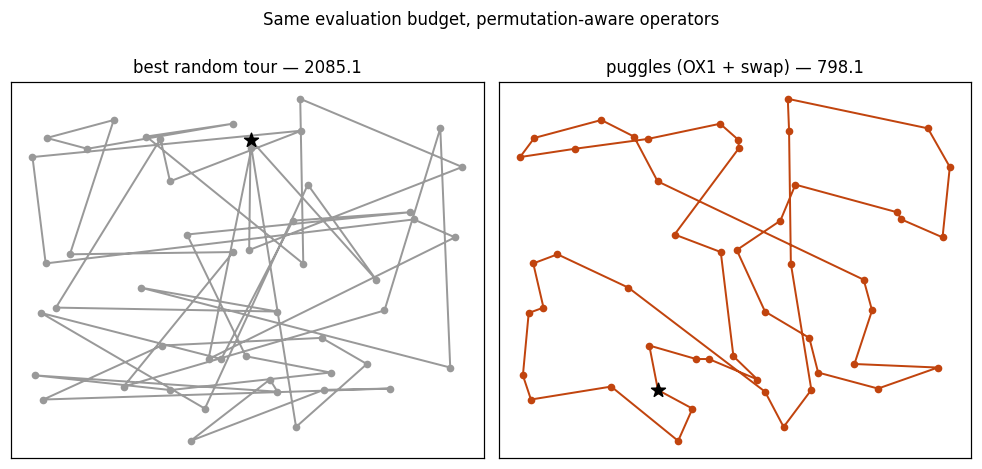

In [9]:
def draw(ax, order, title, color):
    loop = np.append(order, order[0])
    ax.plot(CITIES[loop, 0], CITIES[loop, 1], "-o", ms=4, lw=1.3, color=color)
    ax.scatter(*CITIES[order[0]], s=90, marker="*", color="black", zorder=3)
    ax.set(title=title, xticks=[], yticks=[])

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
draw(axes[0], rand_tour, f"best random tour — {rand_best:.1f}", "#999999")
draw(axes[1], ga_tour, f"puggles (OX1 + swap) — {best.objectives[0]:.1f}", "#c1440e")
fig.suptitle("Same evaluation budget, permutation-aware operators", y=1.0)
fig.tight_layout()
plt.show()

---
## 5. NSGA-III with a batch objective

NSGA-III used to reject batch objectives outright — a batch problem raised an error and you had
to fall back to NSGA-II. It now shares the evaluation path with NSGA-II, so one vectorized call
per generation works for both.

Batching matters most from Python: the objective crosses the FFI boundary once per generation
instead of once per solution. Here the whole population is evaluated in a single numba kernel.

**Problem.** Standard 3-objective DTLZ2. The true front is the unit sphere's positive octant, so
correctness is easy to check: every point should satisfy `‖f‖ = 1`.

In [10]:
from numba import njit, prange

M, N_VAR = 3, 8

@njit(parallel=True, nogil=True, cache=True)
def dtlz2_batch_kernel(xs):
    n = xs.shape[0]
    out = np.empty((n, M), dtype=np.float64)
    for i in prange(n):
        g = 0.0
        for j in range(M - 1, xs.shape[1]):
            g += (xs[i, j] - 0.5) ** 2
        for m in range(M):
            val = 1.0 + g
            for j in range(M - 1 - m):
                val *= np.cos(xs[i, j] * np.pi / 2.0)
            if m > 0:
                val *= np.sin(xs[i, M - 1 - m] * np.pi / 2.0)
            out[i, m] = val
    return out

def dtlz2_batch(population):
    return dtlz2_batch_kernel(np.ascontiguousarray(population, dtype=np.float64)).tolist()

dtlz2_batch_kernel(np.zeros((2, N_VAR)))          # compile before timing

batch_problem = pg.Problem(
    solution_length=N_VAR,
    number_of_objectives=M,
    solution_data_types=[pg.Real(0.0, 1.0)] * N_VAR,
    batch_objective_function=dtlz2_batch,
    direction=[-1] * M,
)

n3 = pg.NSGAIII(batch_problem, population_size=92, divisions=12, seed=1)
n3.run(30_000)

front = np.array([s.objectives for s in n3.get_archive()])
radius = np.linalg.norm(front, axis=1)
print(f"NSGA-III + batch objective: nfe={n3.nfe}, front={len(front)} points")
print(f"‖f‖ over the front: mean {radius.mean():.4f}, max error {abs(radius - 1).max():.4f}  (true front = 1.0)")

NSGA-III + batch objective: nfe=30000, front=92 points
‖f‖ over the front: mean 1.0021, max error 0.0085  (true front = 1.0)


**vs. other libraries.** Same DTLZ2, same population and budget. `puggles NSGA-II (py)` calls the
plain Python `dtlz2` below one solution at a time, like pymoo/platypus/DEAP do — the fairest
comparison of the search itself. `puggles NSGA-III (batch)` is the run above, included so the
FFI-crossing cost of an elementwise objective is visible against it.

In [11]:
import math as _math
import random as _random2
import time as _time2

def dtlz2(x):
    """Plain-Python DTLZ2 — identical math to dtlz2_batch_kernel, one solution at a time."""
    g = sum((x[i] - 0.5) ** 2 for i in range(M - 1, len(x)))
    f = []
    for i in range(M):
        v = 1.0 + g
        for j in range(M - 1 - i):
            v *= _math.cos(x[j] * _math.pi / 2)
        if i > 0:
            v *= _math.sin(x[M - 1 - i] * _math.pi / 2)
        f.append(v)
    return f

from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD
from pymoo.problems import get_problem
from pymoo.util.ref_dirs import get_reference_directions

_ref_dirs = get_reference_directions("das-dennis", M, n_partitions=12)
_hv_ind = HV(ref_point=np.array([1.1] * M))
_igd_ind = IGD(get_problem("dtlz2", n_obj=M).pareto_front(_ref_dirs))

def _score(front):
    F = np.asarray(front, dtype=float)
    return (0.0, float("inf")) if F.size == 0 else (float(_hv_ind(F)), float(_igd_ind(F)))

POP_CMP2, NFE_CMP2 = 92, 30_000  # matches the NSGA-III run above

def _puggles_nsga2():
    p = pg.Problem(N_VAR, M, [pg.Real(0.0, 1.0)] * N_VAR, dtlz2, direction=[-1] * M)
    ga = pg.NSGAII(p, population_size=POP_CMP2, execution_mode="sequential", seed=1)
    t0 = _time2.perf_counter(); ga.run(NFE_CMP2)
    dt = (_time2.perf_counter() - t0) * 1000
    return dt, *_score([list(s.objectives) for s in ga.get_archive()])

def _puggles_nsga3_batch():
    p = pg.Problem(N_VAR, M, [pg.Real(0.0, 1.0)] * N_VAR,
                    batch_objective_function=dtlz2_batch, direction=[-1] * M)
    ga3 = pg.NSGAIII(p, population_size=POP_CMP2, divisions=12, seed=1)
    t0 = _time2.perf_counter(); ga3.run(NFE_CMP2)
    dt = (_time2.perf_counter() - t0) * 1000
    return dt, *_score([list(s.objectives) for s in ga3.get_archive()])

def _pymoo_dtlz2():
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.core.problem import Problem as _P
    from pymoo.optimize import minimize
    class _D(_P):
        def __init__(s): super().__init__(n_var=N_VAR, n_obj=M, xl=0.0, xu=1.0)
        def _evaluate(s, X, out, *a, **k):
            g = ((X[:, M - 1:] - 0.5) ** 2).sum(axis=1)
            cols = []
            for i in range(M):
                v = 1.0 + g
                for j in range(M - 1 - i):
                    v = v * np.cos(X[:, j] * np.pi / 2)
                if i > 0:
                    v = v * np.sin(X[:, M - 1 - i] * np.pi / 2)
                cols.append(v)
            out["F"] = np.column_stack(cols)
    t0 = _time2.perf_counter()
    res = minimize(_D(), NSGA2(pop_size=POP_CMP2), ("n_eval", NFE_CMP2), verbose=False)
    dt = (_time2.perf_counter() - t0) * 1000
    F = res.F if res.F is not None else np.empty((0, M))
    return dt, *_score(F)

def _platypus_dtlz2():
    from platypus import NSGAII as _NS, Problem as _P, Real as _R
    prob = _P(N_VAR, M); prob.types[:] = _R(0, 1); prob.function = dtlz2
    alg = _NS(prob, population_size=POP_CMP2)
    t0 = _time2.perf_counter(); alg.run(NFE_CMP2)
    dt = (_time2.perf_counter() - t0) * 1000
    front = [[s.objectives[k] for k in range(M)] for s in alg.result]
    return dt, *_score(front)

def _deap_dtlz2():
    from deap import base, creator, tools
    if not hasattr(creator, "_D2Fit"):
        creator.create("_D2Fit", base.Fitness, weights=(-1.0,) * M)
    if not hasattr(creator, "_D2Ind"):
        creator.create("_D2Ind", list, fitness=creator._D2Fit)
    tb = base.Toolbox()
    tb.register("attr", _random2.random)
    tb.register("ind", tools.initRepeat, creator._D2Ind, tb.attr, n=N_VAR)
    tb.register("pop", tools.initRepeat, list, tb.ind)
    tb.register("evaluate", dtlz2)
    tb.register("mate", tools.cxSimulatedBinaryBounded, eta=20, low=0.0, up=1.0)
    tb.register("mutate", tools.mutPolynomialBounded, eta=20, low=0.0, up=1.0, indpb=1.0 / N_VAR)
    tb.register("select", tools.selNSGA2)
    gens = (NFE_CMP2 - POP_CMP2) // POP_CMP2
    t0 = _time2.perf_counter()
    pop = tb.pop(n=POP_CMP2)
    for i, f in zip(pop, map(tb.evaluate, pop)):
        i.fitness.values = f
    pop = tb.select(pop, len(pop))
    for _ in range(gens):
        off = [tb.clone(i) for i in tools.selTournamentDCD(pop, len(pop))]
        for a, b in zip(off[::2], off[1::2]):
            if _random2.random() < 0.9:
                tb.mate(a, b)
            tb.mutate(a); tb.mutate(b); del a.fitness.values, b.fitness.values
        for i in off:
            if not i.fitness.valid:
                i.fitness.values = tb.evaluate(i)
        pop = tb.select(pop + off, POP_CMP2)
    dt = (_time2.perf_counter() - t0) * 1000
    ff = tools.sortNondominated(pop, POP_CMP2, first_front_only=True)[0]
    return dt, *_score([list(i.fitness.values) for i in ff])

print(f"# DTLZ2  n={N_VAR}  m={M}  pop={POP_CMP2}  NFE={NFE_CMP2:,}")
print(f"{'library':<24} {'ms':>10} {'HV↑':>9} {'IGD↓':>9}")
print("─" * 54)
for name, fn in [("puggles NSGA-II (py)", _puggles_nsga2),
                  ("puggles NSGA-III (batch)", _puggles_nsga3_batch),
                  ("pymoo", _pymoo_dtlz2), ("platypus", _platypus_dtlz2), ("DEAP", _deap_dtlz2)]:
    ms, hv, igd_v = fn()
    print(f"{name:<24} {ms:>10.1f} {hv:>9.4f} {igd_v:>9.4f}")
print("─" * 54)
print("# HV ref=[1.1]*3 (higher=better).  IGD vs das-dennis front (lower=better).")

# DTLZ2  n=8  m=3  pop=92  NFE=30,000
library                          ms       HV↑      IGD↓
──────────────────────────────────────────────────────
puggles NSGA-II (py)          129.3    0.6764    0.0866


puggles NSGA-III (batch)      129.4    0.7410    0.0040


pymoo                         640.3    0.6929    0.0793


platypus                     3225.4    0.6844    0.0798


DEAP                         2344.7    0.7078    0.0699
──────────────────────────────────────────────────────
# HV ref=[1.1]*3 (higher=better).  IGD vs das-dennis front (lower=better).


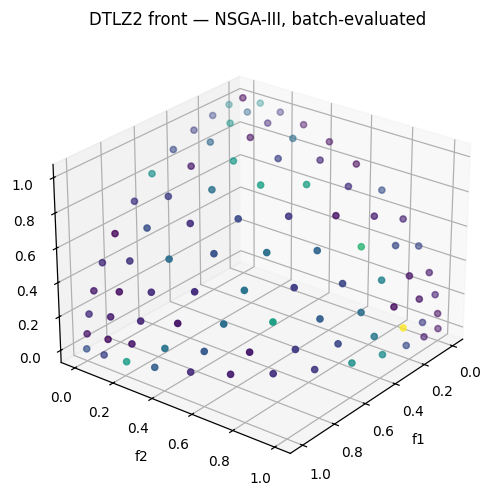

In [12]:
fig = plt.figure(figsize=(5.4, 4.6))
ax = fig.add_subplot(projection="3d")
ax.scatter(front[:, 0], front[:, 1], front[:, 2], s=16, c=radius, cmap="viridis")
ax.set(xlabel="f1", ylabel="f2", zlabel="f3", title="DTLZ2 front — NSGA-III, batch-evaluated")
ax.view_init(elev=26, azim=38)
fig.tight_layout()
plt.show()

---
## 6. Stop when the front stops improving

A fixed evaluation budget either wastes time or cuts the run short. `run_until_hv_converged`
stops when the archive's **hypervolume** plateaus.

Hypervolume is the better signal because it is diversity-aware: it grows both when the front
pushes outward and when it fills in. The older `run_until_converged` watches per-objective bests,
which only sees the front's extent — a run that has stopped extending but is still spreading
looks converged to it.

`hypervolume_2d`, `igd`, and `spacing` are also exposed directly, so you can score a front
without pulling in another library.

In [13]:
def zdt1(x):
    f1 = x[0]
    g = 1.0 + 9.0 * sum(x[1:]) / (len(x) - 1)
    return [f1, g * (1.0 - np.sqrt(f1 / g))]

ZDT_DIM, REF = 6, (1.1, 1.1)   # the standard ZDT1 nadir point
zdt = pg.Problem(ZDT_DIM, 2, [pg.Real(0.0, 1.0)] * ZDT_DIM, zdt1, direction=[-1, -1])

# Trace hypervolume across a long fixed-budget run, for comparison.
trace = []
tracer = pg.NSGAII(zdt, population_size=50, seed=4)
tracer.run(40_000, callback=lambda a, p, nfe: trace.append(
    (nfe, pg.hypervolume_2d([list(s.objectives) for s in a], REF))))

# Now let the run decide for itself when to stop.
auto = pg.NSGAII(zdt, population_size=50, seed=4)
gens = auto.run_until_hv_converged(40_000, REF, patience=15)

print(f"fixed budget : {tracer.nfe:,} evals   HV {trace[-1][1]:.3f}")
print(f"hv-converged : {auto.nfe:,} evals   HV {auto.archive_hypervolume(REF):.3f}   ({gens} generations)")
print(f"saved        : {100 * (1 - auto.nfe / tracer.nfe):.0f}% of the budget")

final = [list(s.objectives) for s in auto.get_archive()]
true_front = [[f1, 1 - np.sqrt(f1)] for f1 in np.linspace(0, 1, 200)]
print(f"\nfront quality — igd {pg.igd(final, true_front):.4f} (lower better), "
      f"spacing {pg.spacing(final):.4f}")

fixed budget : 40,000 evals   HV 0.863
hv-converged : 3,600 evals   HV 0.861   (71 generations)
saved        : 91% of the budget

front quality — igd 0.0125 (lower better), spacing 0.0129


**vs. other libraries.** Same ZDT1, same fixed budget (population 52, not 50, so DEAP's
tournament selection divides evenly). One run each, for a quick read — `bench_python.py` and
`benchmarks.md` have the full multi-seed statistics.

In [14]:
import random as _random3
import time as _time3
import math as _math3

POP_CMP3, NFE_CMP3 = 52, 40_000

_zdt_ref_pts = [(t / 200, 1 - (t / 200) ** 0.5) for t in range(1, 201)]
def _igd_zdt1(pts):
    if not pts:
        return float("inf")
    return sum(min(_math3.hypot(a[0] - r[0], a[1] - r[1]) for a in pts)
               for r in _zdt_ref_pts) / len(_zdt_ref_pts)

def _puggles_zdt1():
    p = pg.NSGAII(zdt, population_size=POP_CMP3, seed=4)
    t0 = _time3.perf_counter(); p.run(NFE_CMP3)
    dt = (_time3.perf_counter() - t0) * 1000
    return dt, _igd_zdt1([(s.objectives[0], s.objectives[1]) for s in p.get_archive()])

def _pymoo_zdt1():
    from pymoo.algorithms.moo.nsga2 import NSGA2
    from pymoo.core.problem import Problem as _P
    from pymoo.optimize import minimize
    class _Z(_P):
        def __init__(s): super().__init__(n_var=ZDT_DIM, n_obj=2, xl=0.0, xu=1.0)
        def _evaluate(s, x, out, *a, **k):
            f1 = x[:, 0]; g = 1 + 9 / (ZDT_DIM - 1) * x[:, 1:].sum(1)
            out["F"] = np.column_stack([f1, g * (1 - np.sqrt(f1 / g))])
    t0 = _time3.perf_counter()
    res = minimize(_Z(), NSGA2(pop_size=POP_CMP3), ("n_eval", NFE_CMP3), verbose=False)
    dt = (_time3.perf_counter() - t0) * 1000
    pts = [(r[0], r[1]) for r in res.F] if res.F is not None else []
    return dt, _igd_zdt1(pts)

def _platypus_zdt1():
    from platypus import NSGAII as _NS, Problem as _P, Real as _R
    prob = _P(ZDT_DIM, 2); prob.types[:] = _R(0, 1); prob.function = zdt1
    alg = _NS(prob, population_size=POP_CMP3)
    t0 = _time3.perf_counter(); alg.run(NFE_CMP3)
    dt = (_time3.perf_counter() - t0) * 1000
    return dt, _igd_zdt1([(s.objectives[0], s.objectives[1]) for s in alg.result])

def _deap_zdt1():
    from deap import base, creator, tools
    if not hasattr(creator, "_ZFit"):
        creator.create("_ZFit", base.Fitness, weights=(-1.0, -1.0))
    if not hasattr(creator, "_ZInd"):
        creator.create("_ZInd", list, fitness=creator._ZFit)
    tb = base.Toolbox()
    tb.register("attr", _random3.random)
    tb.register("ind", tools.initRepeat, creator._ZInd, tb.attr, n=ZDT_DIM)
    tb.register("pop", tools.initRepeat, list, tb.ind)
    tb.register("evaluate", zdt1)
    tb.register("mate", tools.cxSimulatedBinaryBounded, eta=20, low=0.0, up=1.0)
    tb.register("mutate", tools.mutPolynomialBounded, eta=20, low=0.0, up=1.0, indpb=1.0 / ZDT_DIM)
    tb.register("select", tools.selNSGA2)
    gens = (NFE_CMP3 - POP_CMP3) // POP_CMP3
    t0 = _time3.perf_counter()
    pop = tb.pop(n=POP_CMP3)
    for i, f in zip(pop, map(tb.evaluate, pop)):
        i.fitness.values = f
    pop = tb.select(pop, len(pop))
    for _ in range(gens):
        off = [tb.clone(i) for i in tools.selTournamentDCD(pop, len(pop))]
        for a, b in zip(off[::2], off[1::2]):
            if _random3.random() < 0.9:
                tb.mate(a, b)
            tb.mutate(a); tb.mutate(b); del a.fitness.values, b.fitness.values
        for i in off:
            if not i.fitness.valid:
                i.fitness.values = tb.evaluate(i)
        pop = tb.select(pop + off, POP_CMP3)
    dt = (_time3.perf_counter() - t0) * 1000
    ff = tools.sortNondominated(pop, POP_CMP3, first_front_only=True)[0]
    return dt, _igd_zdt1([tuple(i.fitness.values) for i in ff])

print(f"# ZDT1  n={ZDT_DIM}  pop={POP_CMP3}  NFE={NFE_CMP3:,}   metric = IGD (lower=better)")
print(f"{'library':<12} {'ms':>10} {'IGD':>9}")
print("─" * 34)
_zdt_results = {}
for name, fn in [("puggles", _puggles_zdt1), ("pymoo", _pymoo_zdt1),
                  ("platypus", _platypus_zdt1), ("DEAP", _deap_zdt1)]:
    ms, igd_v = fn()
    _zdt_results[name] = (ms, igd_v)
    print(f"{name:<12} {ms:>10.1f} {igd_v:>9.4f}")

_fastest = min(_zdt_results, key=lambda n: _zdt_results[n][0])
_best_igd = min(_zdt_results, key=lambda n: _zdt_results[n][1])
if _fastest != _best_igd:
    speedup = _zdt_results[_best_igd][0] / _zdt_results["puggles"][0]
    gap = 100 * (_zdt_results["puggles"][1] - _zdt_results[_best_igd][1]) / _zdt_results[_best_igd][1]
    print(f"\nhonest tradeoff: puggles is {speedup:.0f}× faster than {_best_igd} at this budget, "
          f"but {_best_igd}'s front IGD is {gap:.0f}% tighter — both converge here, this is noise "
          "at the edge of convergence rather than a real quality gap (see section 6 above).")

# ZDT1  n=6  pop=52  NFE=40,000   metric = IGD (lower=better)
library              ms       IGD
──────────────────────────────────


puggles            80.9    0.0110


pymoo            1059.5    0.0085


platypus         4218.0    0.0082


DEAP             2746.2    0.0099

honest tradeoff: puggles is 52× faster than platypus at this budget, but platypus's front IGD is 34% tighter — both converge here, this is noise at the edge of convergence rather than a real quality gap (see section 6 above).


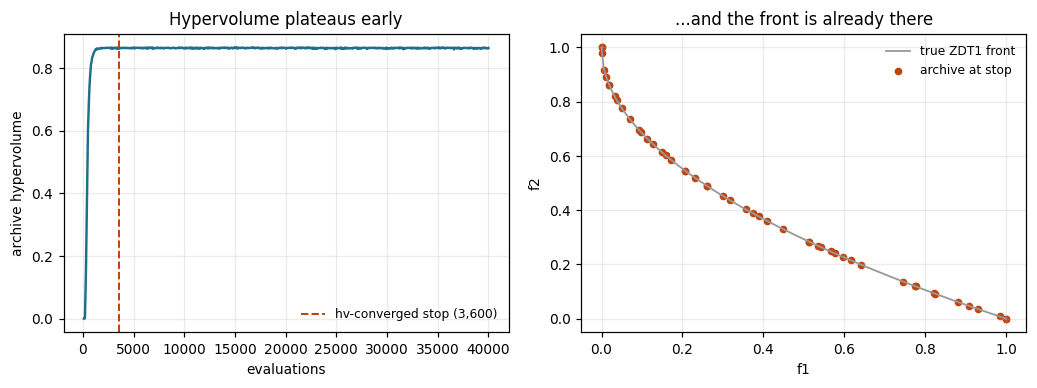

In [15]:
tn, thv = np.array(trace).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.6))

ax1.plot(tn, thv, lw=1.6, color="#1f6f8b")
ax1.axvline(auto.nfe, ls="--", lw=1.3, color="#c1440e",
            label=f"hv-converged stop ({auto.nfe:,})")
ax1.set(xlabel="evaluations", ylabel="archive hypervolume", title="Hypervolume plateaus early")
ax1.legend(frameon=False, fontsize=8, loc="lower right")

ax2.plot([p[0] for p in true_front], [p[1] for p in true_front],
         lw=1.2, color="#999999", label="true ZDT1 front")
ax2.scatter([p[0] for p in final], [p[1] for p in final], s=16,
            color="#c1440e", label="archive at stop")
ax2.set(xlabel="f1", ylabel="f2", title="...and the front is already there")
ax2.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

---
## 7. Island model

One large population shares a single gene pool and can collapse onto one region of the front.
Several smaller populations, run independently and pooled at the end, trade per-island depth for
coverage. Islands are embarrassingly parallel, so they run under Rayon with no coordination.

Island `i` is seeded with `seed + i`: the islands differ from each other, and the whole run still
reproduces exactly for a given base seed.

This needs a native Rust objective — a Python callable is serialized by the GIL, so parallel
islands would add contention without adding throughput. `run_island_model` says so rather than
silently degrading.

**Read the numbers below before reaching for this.** Splitting a budget costs depth: each island
gets a fraction of the evaluations and a smaller population. On a smooth, convex front like this
one, a single population wins, and the measurement says so. Islands earn their keep on rugged or
multimodal landscapes where one population converges early onto a single basin — not here.

In [16]:
NATIVE_DIM = 6
BOUNDS = [(-5.0, 5.0)] * NATIVE_DIM
native = pg.create_benchmark_problem("simple_objective", NATIVE_DIM, 2, BOUNDS)

TOTAL_NFE, ISLANDS = 24_000, 6

single = pg.NSGAII(native, population_size=60, execution_mode="multithreaded", seed=5)
single.run(TOTAL_NFE)
single_front = [list(s.objectives) for s in single.get_archive()]

island_front = [list(s.objectives) for s in pg.run_island_model(
    native, islands=ISLANDS, population_size=30,
    max_nfe_per_island=TOTAL_NFE // ISLANDS, seed=5)]

ref = (2.0, 2.0)
hv_single = pg.hypervolume_2d(single_front, ref)
hv_island = pg.hypervolume_2d(island_front, ref)

print(f"budget: {TOTAL_NFE:,} evaluations either way\n")
print(f"single population : {len(single_front):3d} solutions   HV {hv_single:.4f}   spacing {pg.spacing(single_front):.4f}")
print(f"{ISLANDS} islands        : {len(island_front):3d} solutions   HV {hv_island:.4f}   spacing {pg.spacing(island_front):.4f}")
print(f"\nwinner on this problem: {'islands' if hv_island > hv_single else 'single population'}"
      f"  ({abs(hv_island - hv_single) / hv_single:.1%} difference)")
print("Expected: this front is smooth and convex, so splitting the budget only costs depth.")

again = [list(s.objectives) for s in pg.run_island_model(
    native, islands=ISLANDS, population_size=30,
    max_nfe_per_island=TOTAL_NFE // ISLANDS, seed=5)]
print(f"\nreproducible with the same seed: {sorted(map(tuple, island_front)) == sorted(map(tuple, again))}")

try:
    pg.run_island_model(zdt, islands=2)
except ValueError as e:
    print(f"python callable refused: {str(e)[:72]}...")

budget: 24,000 evaluations either way

single population :  60 solutions   HV 6.4685   spacing 0.0130
6 islands        :  39 solutions   HV 5.4559   spacing 0.0206

winner on this problem: single population  (15.7% difference)
Expected: this front is smooth and convex, so splitting the budget only costs depth.

reproducible with the same seed: True
python callable refused: run_island_model needs a native Rust objective — a Python callable is se...


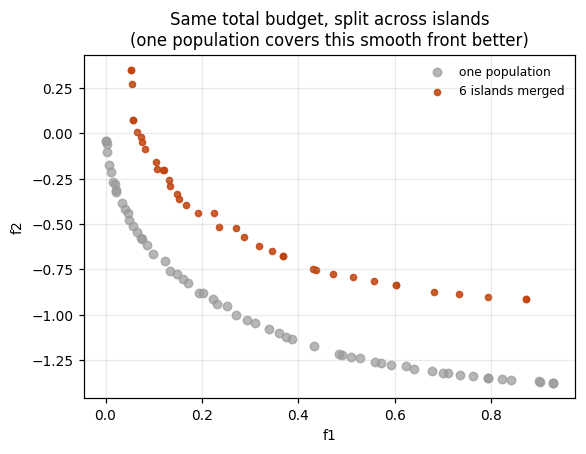

In [17]:
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.scatter(*np.array(single_front).T, s=30, alpha=0.7, label="one population", color="#999999")
ax.scatter(*np.array(island_front).T, s=16, alpha=0.85, label=f"{ISLANDS} islands merged", color="#c1440e")
ax.set(xlabel="f1", ylabel="f2",
       title="Same total budget, split across islands\n(one population covers this smooth front better)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

---
## 8. Checkpoint and resume

`save_state()` returns JSON holding the evolved data — decision variables and evaluation results.
The objective function is *not* stored, because it is a Python callable. To resume, rebuild the
same problem, `load_state()`, and call `run()` with the **cumulative** budget: evaluations
already spent are not repeated.

In [18]:
import json

first = pg.NSGAII(zdt, population_size=50, seed=6)
first.run(8_000)
checkpoint = first.save_state()

parsed = json.loads(checkpoint)
print(f"checkpoint : {len(checkpoint):,} bytes — nfe={parsed['nfe']}, "
      f"population={len(parsed['population'])}, archive={len(parsed['archive'])}")
print(f"per-solution fields: {sorted(parsed['population'][0])}")

hv_at_pause = first.archive_hypervolume(REF)

# ... process restarts here; only the JSON survives ...
resumed = pg.NSGAII(zdt, population_size=50, seed=6)
resumed.load_state(checkpoint)
resumed.run(24_000)                     # cumulative budget

print(f"\npaused at  : {first.nfe:,} evals   HV {hv_at_pause:.4f}")
print(f"resumed to : {resumed.nfe:,} evals   HV {resumed.archive_hypervolume(REF):.4f}")
print(f"resumed run continued from the checkpoint rather than restarting: {resumed.nfe > first.nfe}")
print("\nThe hypervolume barely moves, and that is the expected result: section 6 measured")
print(f"convergence at ~{auto.nfe:,} evaluations, so everything after that is refinement noise.")
print("Archive membership is capped and pruned by crowding distance, so HV can wobble slightly")
print("in either direction once the front has settled.")

checkpoint : 32,009 bytes — nfe=8000, population=50, archive=50
per-solution fields: ['constraint_values', 'constraint_violation', 'constraint_violation_magnitude', 'evaluated', 'feasible', 'objective_fitness_values', 'solution']



paused at  : 8,000 evals   HV 0.8630
resumed to : 24,000 evals   HV 0.8604
resumed run continued from the checkpoint rather than restarting: True

The hypervolume barely moves, and that is the expected result: section 6 measured
convergence at ~3,600 evaluations, so everything after that is refinement noise.
Archive membership is capped and pruned by crowding distance, so HV can wobble slightly
in either direction once the front has settled.


---
## Where to go next

- `sandbox/examples/` — the same ideas as standalone Rust programs, including GPU evaluation.
- `sandbox/bench_python.py`, `sandbox/bench_dtlz.py`, `sandbox/benchmarks.md` — the full 5-way
  comparison (native Rust + Python bindings vs. pymoo, platypus, DEAP) with multiple seeds and
  stdev, plus the single-objective and large-data benchmarks this notebook doesn't cover.
- `GUIDE.md` — the full walkthrough, including Rust-only features such as decision-variable
  constraints `g(x) ≤ 0` and custom operator managers.